In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors


In [ ]:
blob = pd.read_csv('/content/cluster_blobs.csv')
moon = pd.read_csv('/content/cluster_moons.csv')
circle = pd.read_csv('/content/cluster_circles.csv')

datasets = {
    "Blob": blob,
    "Moon": moon,
    "Circle": circle
}


In [ ]:
for name, df in datasets.items():
    print(f"\n{name} Dataset")
    print(df.head())
    print("Shape:", df.shape)



Blob Dataset
         X1        X2
0  4.645333  6.822294
1  4.784032  6.422883
2 -5.851786  5.774331
3 -7.459592  6.456415
4  4.918911  6.961479
Shape: (1500, 2)

Moon Dataset
        X_1       X_2
0  0.674362 -0.444625
1  1.547129 -0.239796
2  1.601930 -0.230792
3  0.014563  0.449752
4  1.503476 -0.389164
Shape: (1500, 2)

Circle Dataset
         X1        X2
0 -0.348677  0.010157
1 -0.176587 -0.954283
2  0.301703 -0.113045
3 -0.782889 -0.719468
4 -0.733280 -0.757354
Shape: (1500, 2)


**Part - A**


Dataset: Blob
Number of samples: 1500
Correlation between features: -0.0497


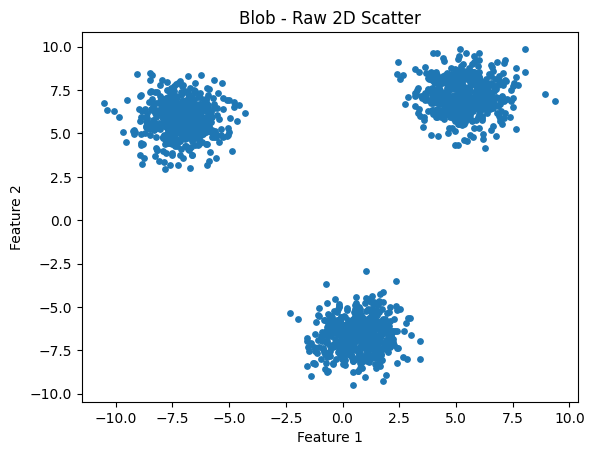


Dataset: Moon
Number of samples: 1500
Correlation between features: -0.4489


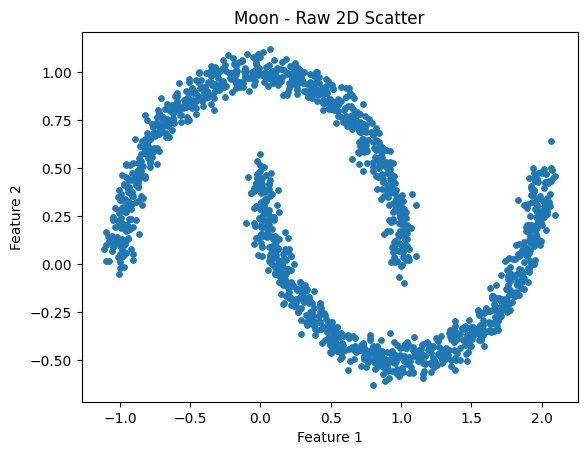


Dataset: Circle
Number of samples: 1500
Correlation between features: 0.0023


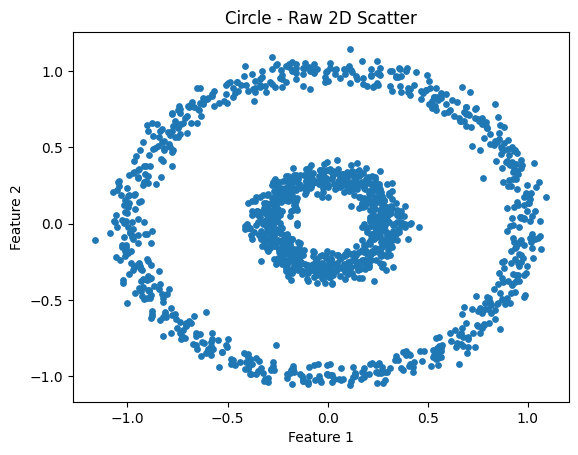

In [ ]:
for name, df in datasets.items():

    X = df.values

    print(f"\nDataset: {name}")
    print("Number of samples:", X.shape[0])

    corr = df.corr().iloc[0,1]
    print("Correlation between features:", round(corr,4))

    plt.figure()
    plt.scatter(X[:,0], X[:,1], s=15)
    plt.title(f"{name} - Raw 2D Scatter")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


**Part - B**


Dataset: Blob
Explained Variance Ratio: [0.59713182 0.40286818]


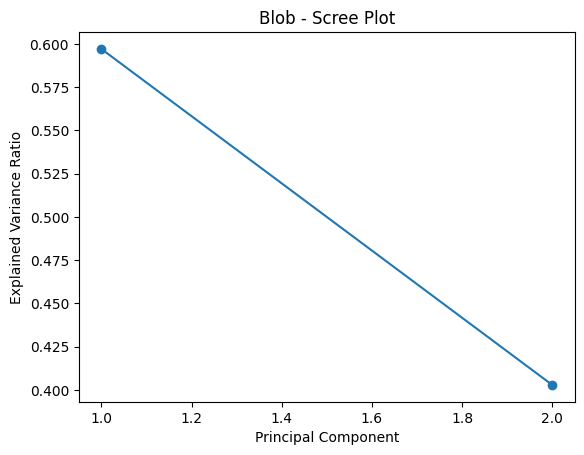

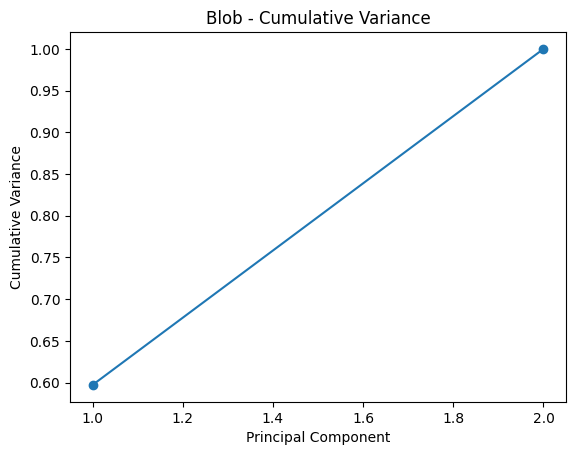

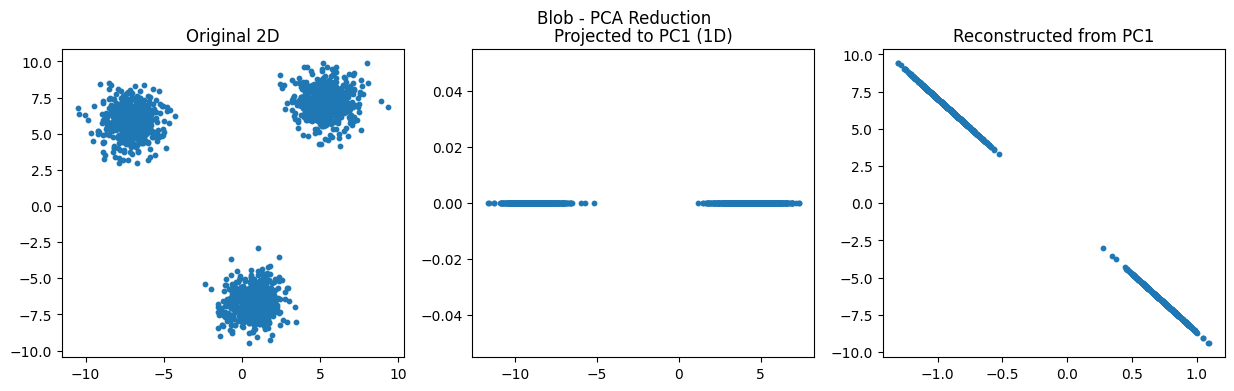


Dataset: Moon
Explained Variance Ratio: [0.81894379 0.18105621]


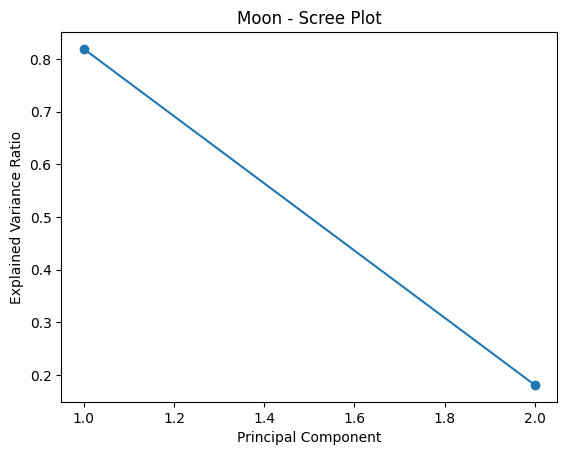

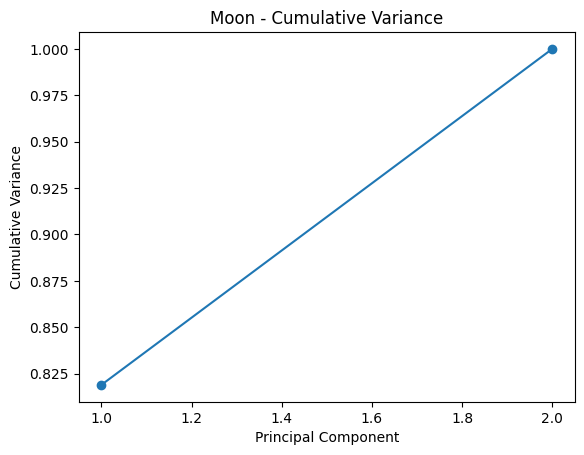

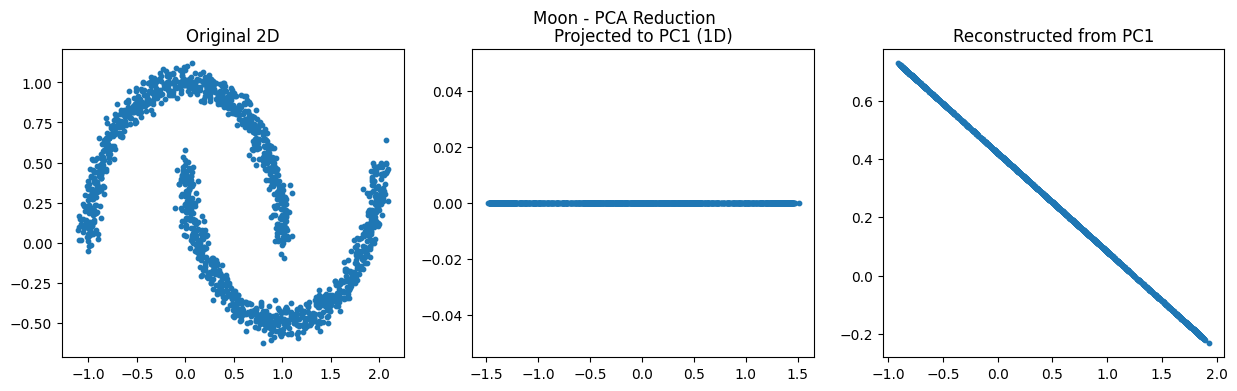


Dataset: Circle
Explained Variance Ratio: [0.50340913 0.49659087]


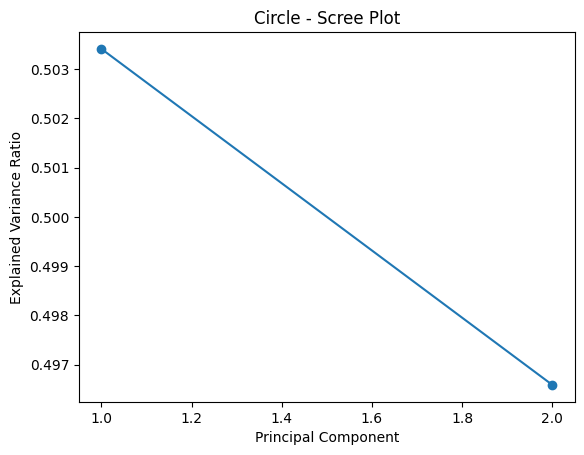

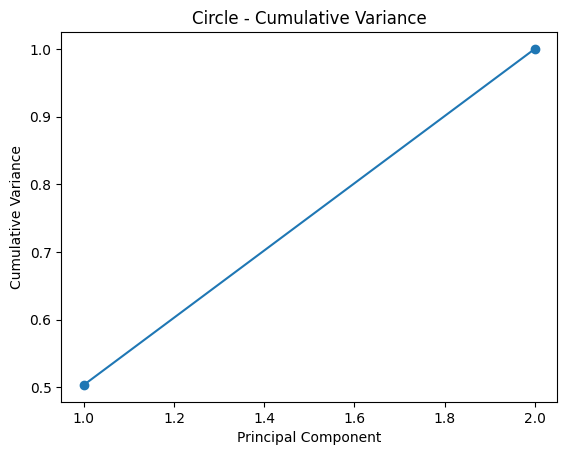

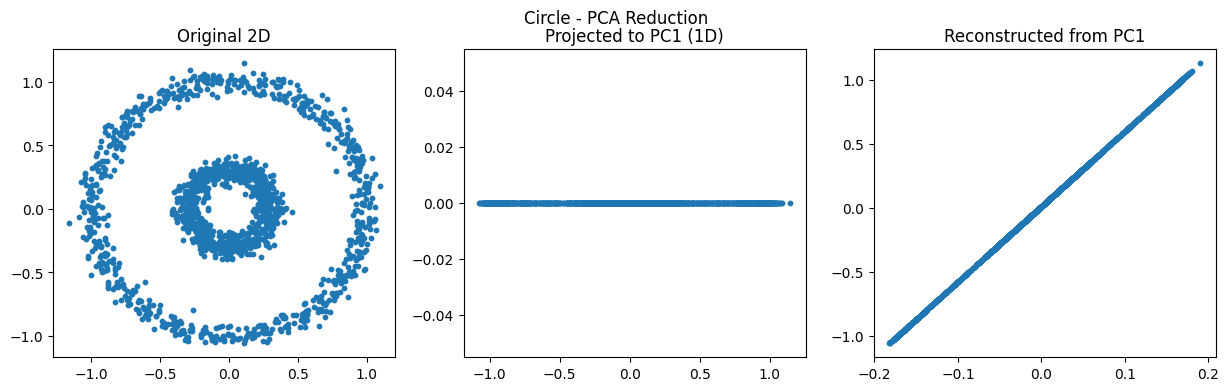

In [ ]:
pca_results = {}

for name, df in datasets.items():

    X = df.values

    print(f"\nDataset: {name}")

    # Apply PCA (2 components)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    print("Explained Variance Ratio:", pca.explained_variance_ratio_)

    # Scree Plot
    plt.figure()
    plt.plot([1,2], pca.explained_variance_ratio_, marker='o')
    plt.title(f"{name} - Scree Plot")
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.show()

    # Cumulative Variance Plot
    plt.figure()
    plt.plot([1,2], np.cumsum(pca.explained_variance_ratio_), marker='o')
    plt.title(f"{name} - Cumulative Variance")
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance")
    plt.show()

    # Reduce to 1D
    pca_1d = PCA(n_components=1)
    X_1d = pca_1d.fit_transform(X)

    # Reconstruction
    X_reconstructed = pca_1d.inverse_transform(X_1d)

    # Visualization
    plt.figure(figsize=(15,4))

    # Original
    plt.subplot(1,3,1)
    plt.scatter(X[:,0], X[:,1], s=10)
    plt.title("Original 2D")

    # 1D Projection
    plt.subplot(1,3,2)
    plt.scatter(X_1d, np.zeros_like(X_1d), s=10)
    plt.title("Projected to PC1 (1D)")

    # Reconstructed
    plt.subplot(1,3,3)
    plt.scatter(X_reconstructed[:,0], X_reconstructed[:,1], s=10)
    plt.title("Reconstructed from PC1")

    plt.suptitle(f"{name} - PCA Reduction")
    plt.show()

    pca_results[name] = {
        "original": X,
        "1d": X_1d
    }


**Part - C**

k-distance graph

In [ ]:
def plot_k_distance(X, min_samples, title):

    neigh = NearestNeighbors(n_neighbors=min_samples)
    neigh.fit(X)

    distances, _ = neigh.kneighbors(X)

    # distance to kth nearest neighbor
    k_distances = np.sort(distances[:, -1])

    plt.figure()
    plt.plot(k_distances)
    plt.title(f"{title} - k Distance Graph")
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"{min_samples}th Nearest Neighbor Distance")
    plt.show()

    return k_distances


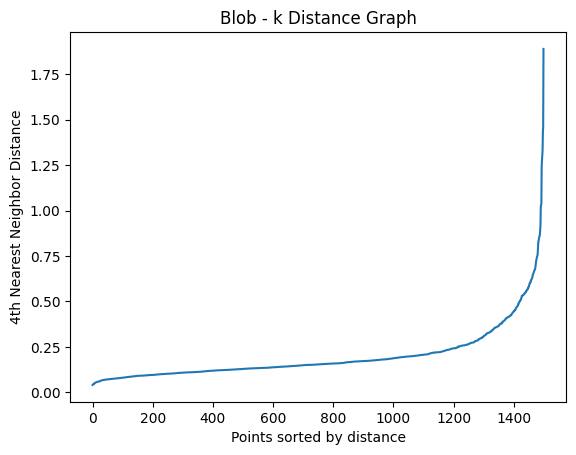

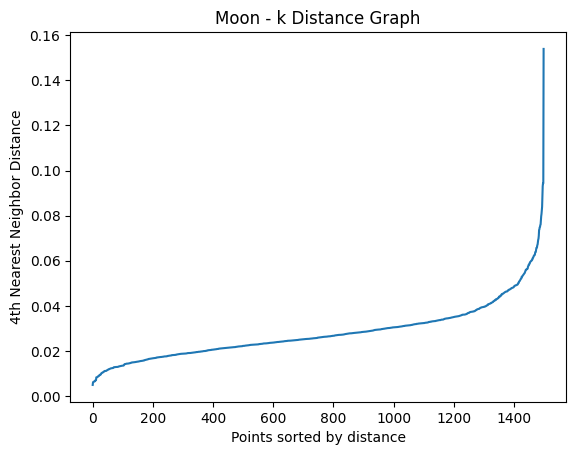

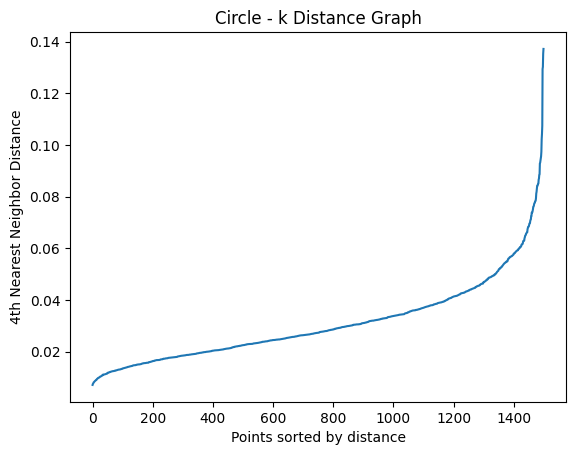

In [ ]:
eps_values = {}

for name, df in datasets.items():

    X = df.values

    k_distances = plot_k_distance(X, min_samples=4, title=name)   # You must visually inspect elbow and decide eps


EPS values

In [ ]:
eps_values = {
    "Blob": 0.5,
    "Moon": 0.05,
    "Circle": 0.07
}
min_samples = 4



Dataset: Blob
Number of clusters: 3
Number of noise points: 50
Silhouette Score: 0.7868


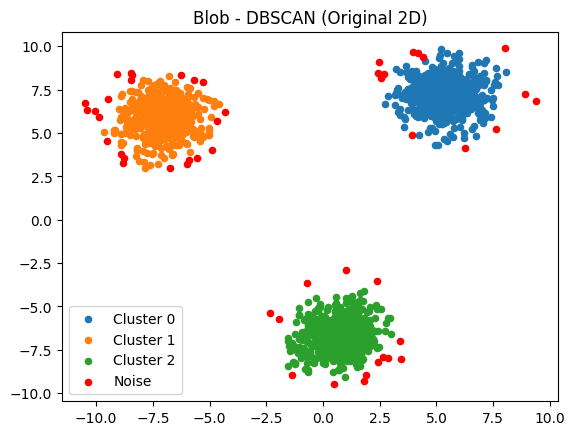


Dataset: Moon
Number of clusters: 2
Number of noise points: 32
Silhouette Score: 0.1937


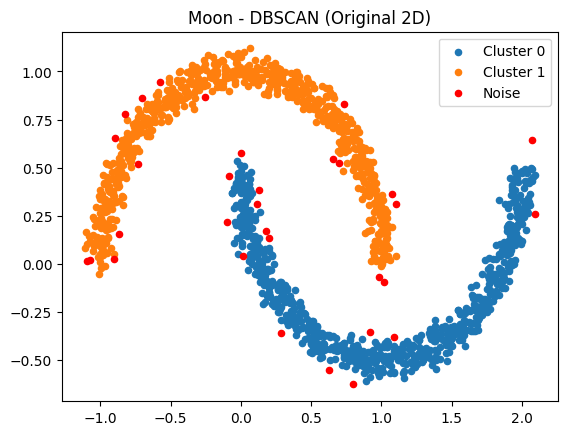


Dataset: Circle
Number of clusters: 2
Number of noise points: 14
Silhouette Score: 0.1945


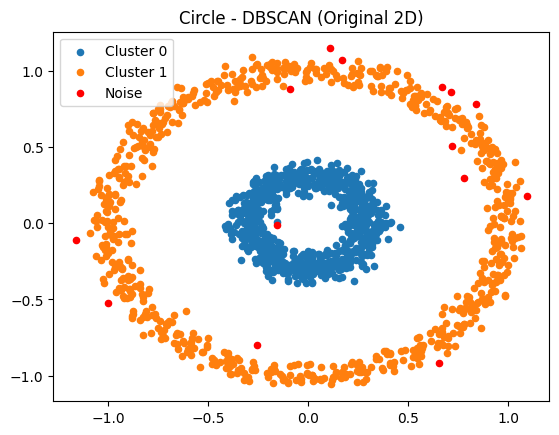

In [ ]:
dbscan_results = {}

for name, df in datasets.items():

    X = df.values

    db = DBSCAN(eps=eps_values[name], min_samples=min_samples)
    labels = db.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"\nDataset: {name}")
    print("Number of clusters:", n_clusters)
    print("Number of noise points:", n_noise)

    if n_clusters > 1:
        sil = silhouette_score(X, labels)
        print("Silhouette Score:", round(sil,4))
    else:
        print("Silhouette Score: Not Applicable")

    # Visualization
    plt.figure()

    unique_labels = set(labels)

    for label in unique_labels:
        if label == -1:
            plt.scatter(X[labels == label, 0],
                        X[labels == label, 1],
                        c='red', s=20, label='Noise')
        else:
            plt.scatter(X[labels == label, 0],
                        X[labels == label, 1],
                        s=20, label=f'Cluster {label}')

    plt.title(f"{name} - DBSCAN (Original 2D)")
    plt.legend()
    plt.show()

    dbscan_results[name] = {
        "labels": labels,
        "clusters": n_clusters,
        "noise": n_noise
    }


# Part - D

In [ ]:
pca_1d_data = {}

for name, df in datasets.items():

    X = df.values

    pca = PCA(n_components=1)
    X_1d = pca.fit_transform(X)

    pca_1d_data[name] = X_1d


In [ ]:
def plot_k_distance_1d(X_1d, min_samples, title):

    neigh = NearestNeighbors(n_neighbors=min_samples)
    neigh.fit(X_1d)

    distances, _ = neigh.kneighbors(X_1d)

    k_distances = np.sort(distances[:, -1])

    plt.figure()
    plt.plot(k_distances)
    plt.title(f"{title} - 1D k Distance Graph")
    plt.xlabel("Points sorted")
    plt.ylabel("Distance")
    plt.show()

    return k_distances


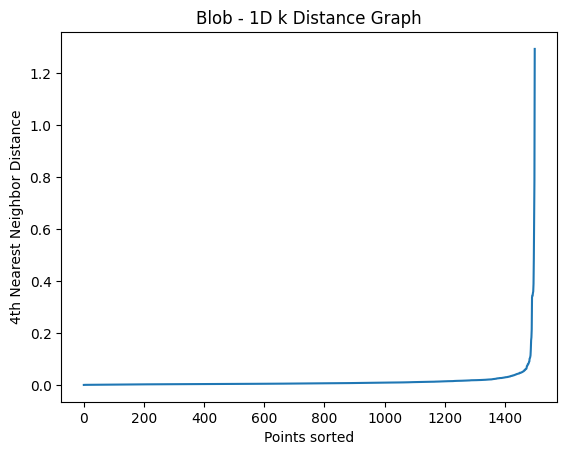

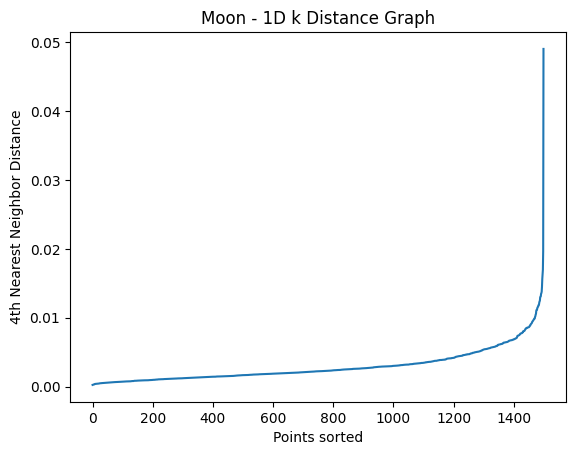

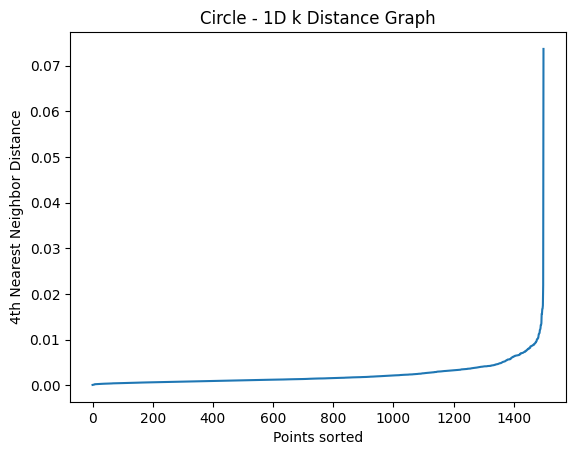

In [ ]:
eps_1d_candidates = {}

for name in datasets.keys():

    X_1d = pca_1d_data[name]

    neigh = NearestNeighbors(n_neighbors=4)
    neigh.fit(X_1d)

    distances, _ = neigh.kneighbors(X_1d)

    k_distances = np.sort(distances[:, -1])

    plt.figure()
    plt.plot(k_distances)
    plt.title(f"{name} - 1D k Distance Graph")
    plt.xlabel("Points sorted")
    plt.ylabel("4th Nearest Neighbor Distance")
    plt.show()


In [ ]:
eps_1d = {
    "Blob": 0.111,
    "Moon": 0.017,
    "Circle": 0.013
}


In [ ]:
dbscan_1d_results = {}

for name in datasets.keys():

    X_1d = pca_1d_data[name]

    db = DBSCAN(eps=eps_1d[name], min_samples=4)
    labels = db.fit_predict(X_1d)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"\n{name} - 1D DBSCAN")
    print("Clusters:", n_clusters)
    print("Noise:", n_noise)

    if n_clusters > 1:
        sil = silhouette_score(X_1d, labels)
        print("Silhouette Score:", round(sil,4))
    else:
        print("Silhouette: Not applicable")

    dbscan_1d_results[name] = labels



Blob - 1D DBSCAN
Clusters: 3
Noise: 13
Silhouette Score: 0.5884

Moon - 1D DBSCAN
Clusters: 2
Noise: 1
Silhouette Score: 0.3547

Circle - 1D DBSCAN
Clusters: 2
Noise: 4
Silhouette Score: 0.4325


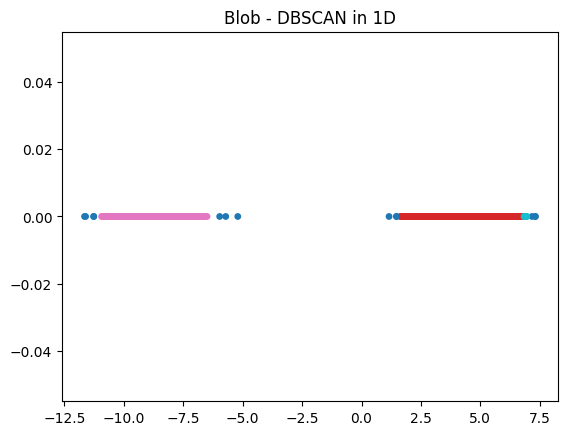

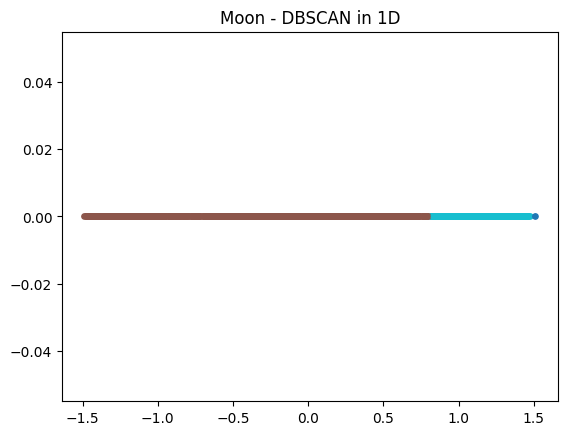

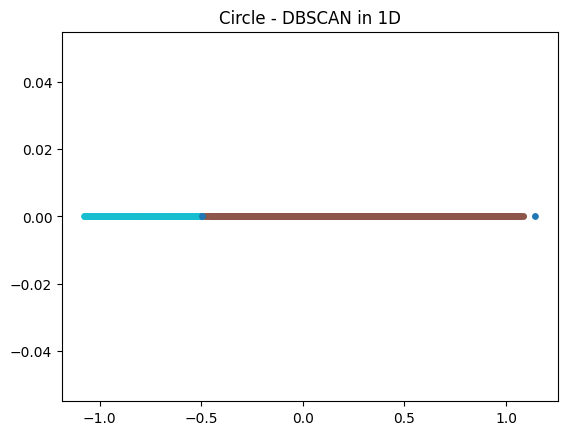

In [ ]:
for name in datasets.keys():

    X_1d = pca_1d_data[name]
    labels = dbscan_1d_results[name]

    plt.figure()
    plt.scatter(X_1d, np.zeros_like(X_1d), c=labels, cmap='tab10', s=15)
    plt.title(f"{name} - DBSCAN in 1D")
    plt.show()


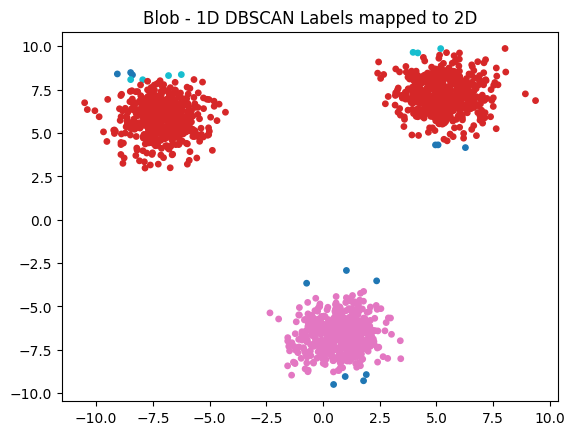

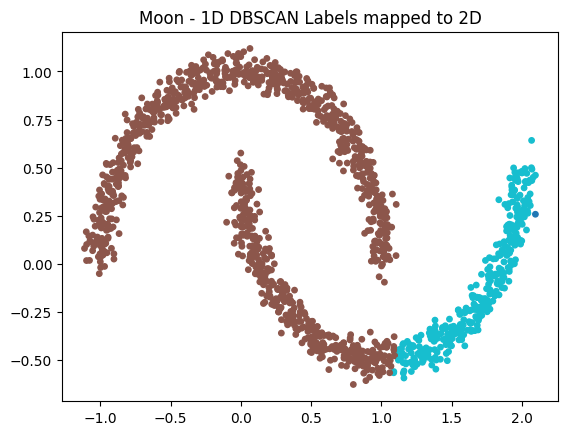

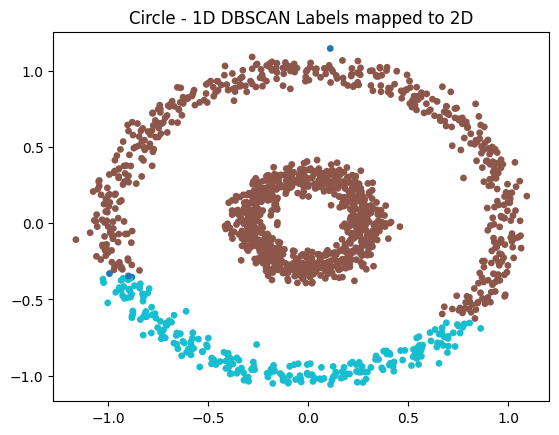

In [ ]:
for name, df in datasets.items():

    X = df.values
    labels = dbscan_1d_results[name]

    plt.figure()
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', s=15)
    plt.title(f"{name} - 1D DBSCAN Labels mapped to 2D")
    plt.show()


**Part E**


Blob - KMeans (2D)
Silhouette Score: 0.8625


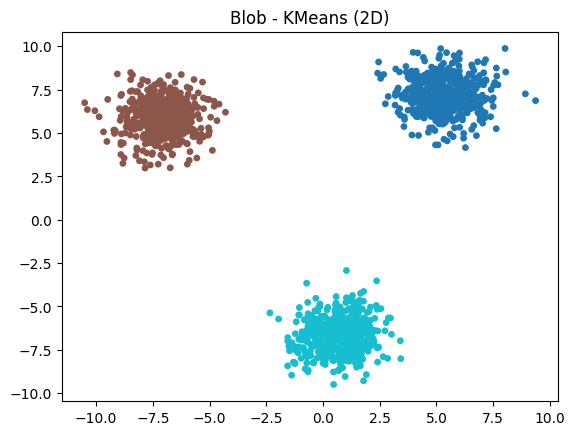


Moon - KMeans (2D)
Silhouette Score: 0.4904


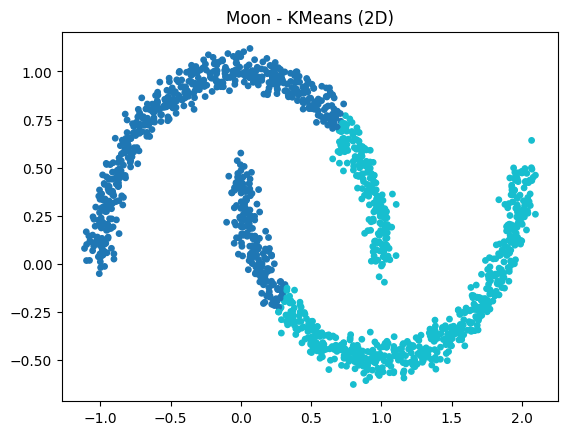


Circle - KMeans (2D)
Silhouette Score: 0.2932


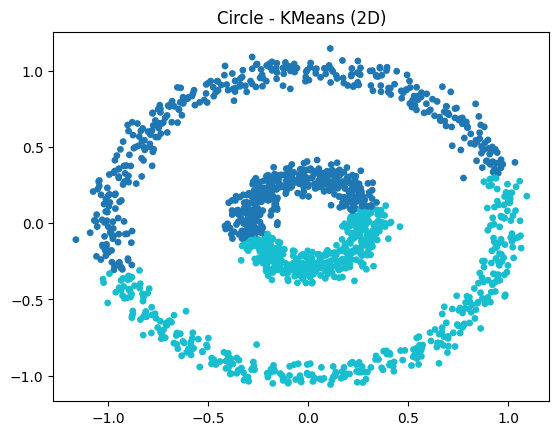

In [ ]:
kmeans_2d_results = {}

for name, df in datasets.items():

    X = df.values

    n_clusters = dbscan_results[name]["clusters"]

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    sil = silhouette_score(X, labels)

    print(f"\n{name} - KMeans (2D)")
    print("Silhouette Score:", round(sil,4))

    # Visualization
    plt.figure()
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', s=15)
    plt.title(f"{name} - KMeans (2D)")
    plt.show()

    kmeans_2d_results[name] = labels


In [ ]:
kmeans_1d_results = {}

for name in datasets.keys():

    X_1d = pca_1d_data[name]

    n_clusters = dbscan_results[name]["clusters"]

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_1d)

    sil = silhouette_score(X_1d, labels)

    print(f"\n{name} - KMeans (1D)")
    print("Silhouette Score:", round(sil,4))

    kmeans_1d_results[name] = labels



Blob - KMeans (1D)
Silhouette Score: 0.6754

Moon - KMeans (1D)
Silhouette Score: 0.6014

Circle - KMeans (1D)
Silhouette Score: 0.536


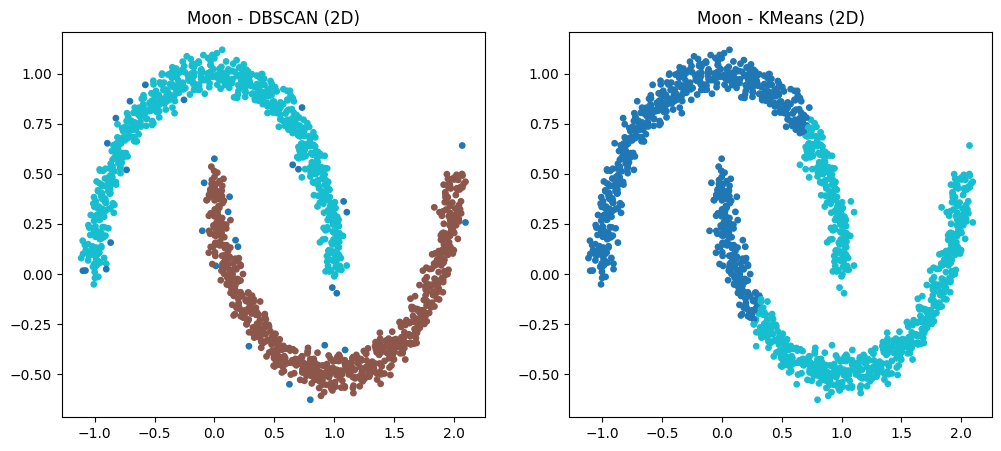

In [ ]:
# Moon comparison
X_moon = datasets["Moon"].values

plt.figure(figsize=(12,5))

# DBSCAN
plt.subplot(1,2,1)
plt.scatter(X_moon[:,0], X_moon[:,1],
            c=dbscan_results["Moon"]["labels"],
            cmap='tab10', s=15)
plt.title("Moon - DBSCAN (2D)")

# KMeans
plt.subplot(1,2,2)
plt.scatter(X_moon[:,0], X_moon[:,1],
            c=kmeans_2d_results["Moon"],
            cmap='tab10', s=15)
plt.title("Moon - KMeans (2D)")

plt.show()
